In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nicapotato_womens_ecommerce_clothing_reviews_path = kagglehub.dataset_download('nicapotato/womens-ecommerce-clothing-reviews')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os

# Check karo dataset ka exact folder name aur file path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nicapotato/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv


In [ ]:
import pandas as pd

file_path = "/kaggle/input/datasets/nicapotato/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv"

df = pd.read_csv(file_path)
df.head()


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
# 1. removing the missing reviews
df = df[['Review Text', 'Rating', 'Department Name']].dropna(subset=['Review Text'])

# 2. removing neutral reviews and only keeping the positive and negative ones
df = df[df['Rating'] != 3]

# 4&5 stars are positive(1) and 1&2 are negative (0)
df['Sentiment'] = df['Rating'].apply(lambda x: 1 if x > 3 else 0)

# Check count: Positive vs Negative
print("Sentiment distribution:")
print(df['Sentiment'].value_counts())
df.head()

Sentiment distribution:
Sentiment
1    17448
0     2370
Name: count, dtype: int64


,Review Text,Rating,Department Name,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,Intimate,1
1,Love this dress! it's sooo pretty. i happene...,5,Dresses,1
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Bottoms,1
4,This shirt is very flattering to all due to th...,5,Tops,1
5,"I love tracy reese dresses, but this one is no...",2,Dresses,0


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize, remove stopwords, and lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(cleaned_words)

# Apply text cleaning to Review Text
df['Cleaned_Review'] = df['Review Text'].apply(clean_text)

# Preview the cleaned text
df[['Review Text', 'Cleaned_Review', 'Sentiment']].head()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Review Text,Cleaned_Review,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable,1
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...,1
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...,1
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...,1
5,"I love tracy reese dresses, but this one is no...",love tracy reese dress one petite foot tall us...,0


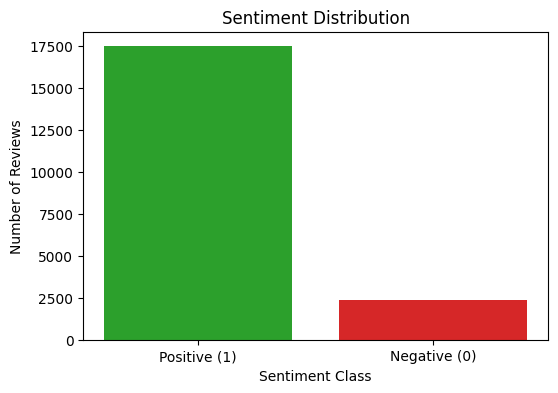

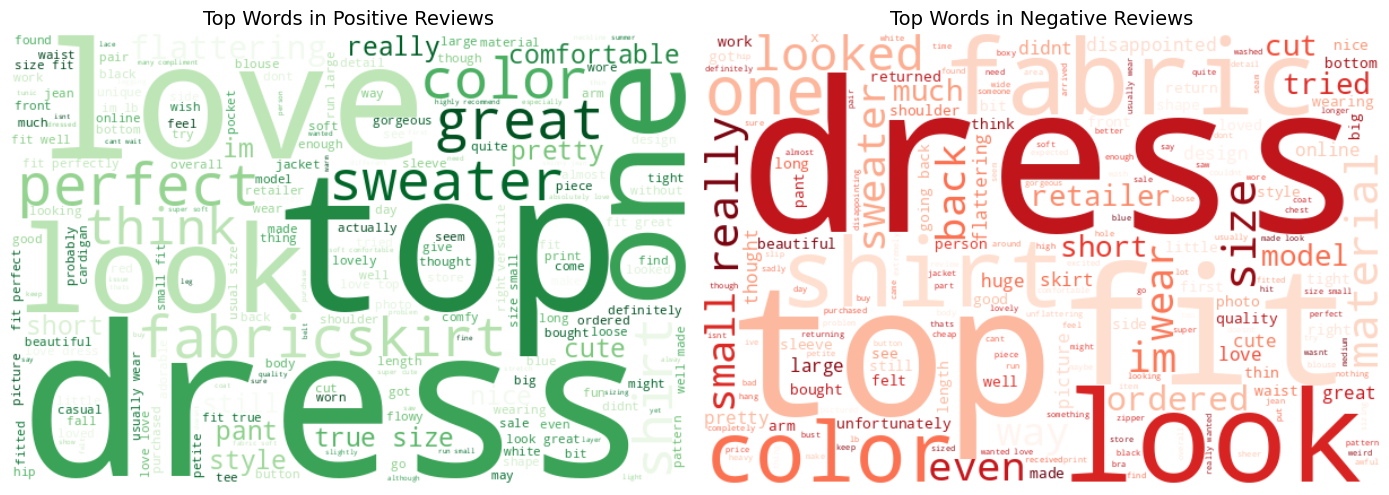

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Plot Sentiment Distribution
plt.figure(figsize=(6, 4))
plt.bar(['Positive (1)', 'Negative (0)'], df['Sentiment'].value_counts(), color=['#2ca02c', '#d62728'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Reviews')
plt.show()

# 2. Generate WordClouds
pos_reviews = " ".join(df[df['Sentiment'] == 1]['Cleaned_Review'])
neg_reviews = " ".join(df[df['Sentiment'] == 0]['Cleaned_Review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive WordCloud
wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(pos_reviews)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Top Words in Positive Reviews', fontsize=14)
axes[0].axis('off')

# Negative WordCloud
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(neg_reviews)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Top Words in Negative Reviews', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.83      0.49      0.61       474
Positive (1)       0.93      0.99      0.96      3490

    accuracy                           0.93      3964
   macro avg       0.88      0.74      0.79      3964
weighted avg       0.92      0.93      0.92      3964



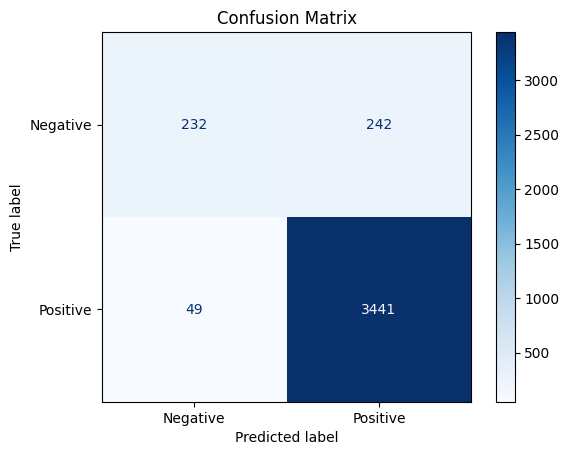

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Define Features (X) and Target (y)
X = df['Cleaned_Review']
y = df['Sentiment']

# 2. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 4. Model Training: Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 5. Predictions & Evaluation
y_pred = model.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

# 6. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import numpy as np

# 1. Function to test custom user reviews
def predict_sentiment(sample_text):
    cleaned = clean_text(sample_text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    prob = model.predict_proba(vectorized)[0]
    label = "Positive" if prediction == 1 else "Negative"
    confidence = prob[1] if prediction == 1 else prob[0]
    return f"Review: '{sample_text}' --> Sentiment: {label} ({confidence*100:.1f}% confidence)"

# Test sample clothing reviews
print(predict_sentiment("The fabric is very cheap, stitching came off, and the fit is terrible."))
print(predict_sentiment("Absolutely gorgeous dress! Soft material and fits true to size."))

# 2. Extract Top 10 Words Indicating Positive vs. Negative Sentiment
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = model.coef_[0]

top_negative_words = feature_names[np.argsort(coefficients)[:10]]
top_positive_words = feature_names[np.argsort(coefficients)[-10:]]

print("\n--- Business Driver Keywords ---")
print("Top Negative Drivers:", list(top_negative_words))
print("Top Positive Drivers:", list(reversed(top_positive_words)))

Review: 'The fabric is very cheap, stitching came off, and the fit is terrible.' --> Sentiment: Negative (95.5% confidence)
Review: 'Absolutely gorgeous dress! Soft material and fits true to size.' --> Sentiment: Positive (99.0% confidence)

--- Business Driver Keywords ---
Top Negative Drivers: ['disappointed', 'wanted', 'cheap', 'unflattering', 'returned', 'looked', 'huge', 'awful', 'back', 'return']
Top Positive Drivers: ['love', 'little', 'comfortable', 'great', 'perfect', 'soft', 'bit', 'compliment', 'perfectly', 'happy']


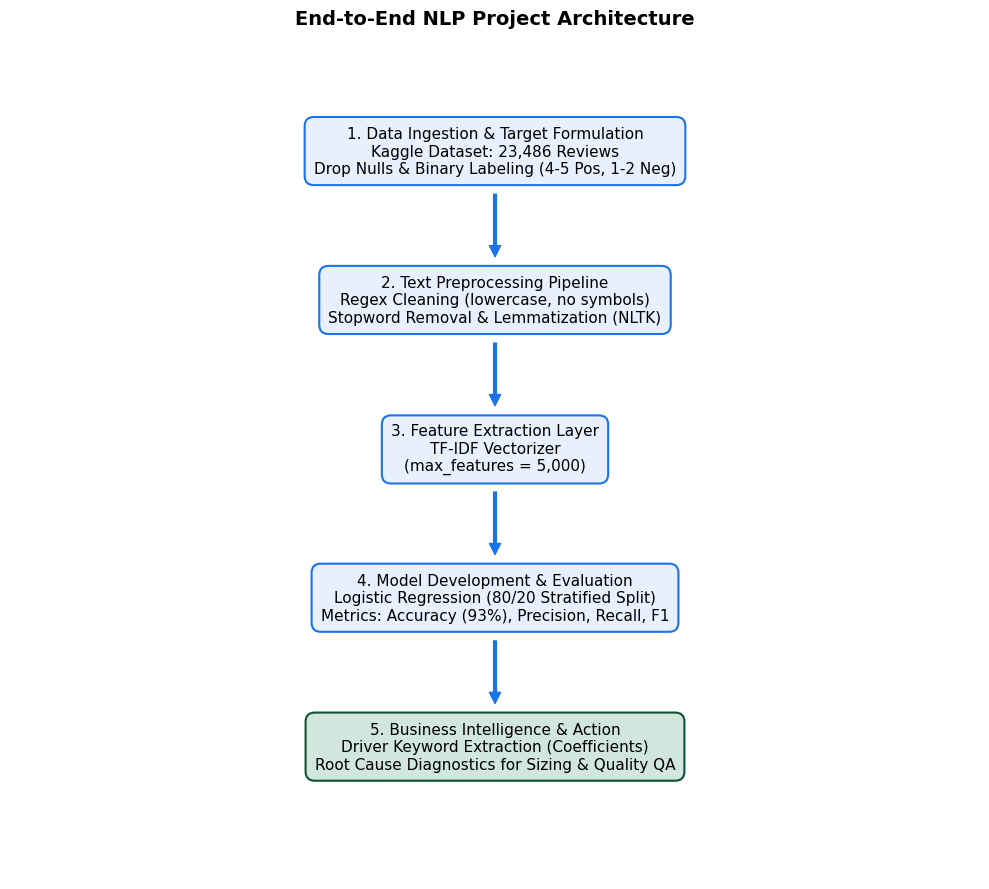

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 9))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Box styling
box_style = dict(boxstyle="round,pad=0.6", fc="#E8F0FE", ec="#1A73E8", lw=1.5)
highlight_style = dict(boxstyle="round,pad=0.6", fc="#D1E7DD", ec="#0F5132", lw=1.5)

# (Title, Description, Center Y-coordinate)
steps = [
    ("1. Data Ingestion & Target Formulation", "Kaggle Dataset: 23,486 Reviews\nDrop Nulls & Binary Labeling (4-5 Pos, 1-2 Neg)", 0.88),
    ("2. Text Preprocessing Pipeline", "Regex Cleaning (lowercase, no symbols)\nStopword Removal & Lemmatization (NLTK)", 0.70),
    ("3. Feature Extraction Layer", "TF-IDF Vectorizer\n(max_features = 5,000)", 0.52),
    ("4. Model Development & Evaluation", "Logistic Regression (80/20 Stratified Split)\nMetrics: Accuracy (93%), Precision, Recall, F1", 0.34),
    ("5. Business Intelligence & Action", "Driver Keyword Extraction (Coefficients)\nRoot Cause Diagnostics for Sizing & Quality QA", 0.16)
]

# Draw boxes
for title, desc, y_center in steps:
    style = highlight_style if "Business" in title else box_style
    ax.text(0.5, y_center, f"{title}\n{desc}", ha='center', va='center', fontsize=11, bbox=style)

# Draw arrows between adjacent boxes (Top box bottom -> Lower box top)
for i in range(len(steps) - 1):
    y_start = steps[i][2] - 0.048    # Bottom edge of upper box
    y_end = steps[i+1][2] + 0.048    # Top edge of lower box

    ax.annotate(
        '',
        xy=(0.5, y_end),
        xytext=(0.5, y_start),
        arrowprops=dict(
            facecolor='#1A73E8',
            edgecolor='#1A73E8',
            width=2,
            headwidth=8,
            headlength=8,
            shrink=0.05
        )
    )

plt.title("End-to-End NLP Project Architecture", fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig("nlp_architecture_fixed.png", dpi=300)
plt.show()

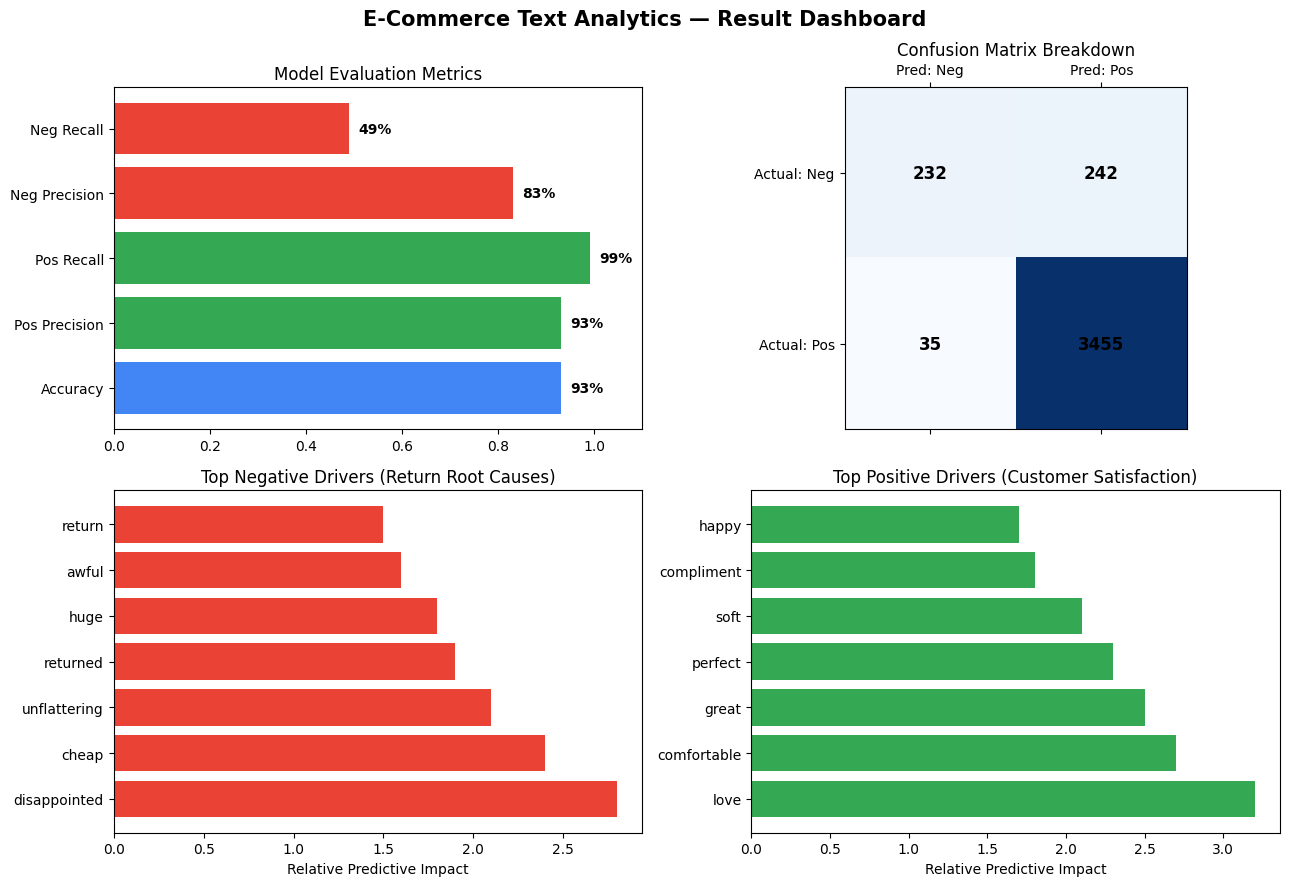

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("E-Commerce Text Analytics — Result Dashboard", fontsize=15, weight='bold')

# Panel 1: Overall Performance Metrics
metrics = ['Accuracy', 'Pos Precision', 'Pos Recall', 'Neg Precision', 'Neg Recall']
scores = [0.93, 0.93, 0.99, 0.83, 0.49]
axs[0, 0].barh(metrics, scores, color=['#4285F4', '#34A853', '#34A853', '#EA4335', '#EA4335'])
axs[0, 0].set_xlim(0, 1.1)
for i, v in enumerate(scores):
    axs[0, 0].text(v + 0.02, i, f"{v*100:.0f}%", va='center', weight='bold')
axs[0, 0].set_title("Model Evaluation Metrics")

# Panel 2: Confusion Matrix Summary
cm_data = [[232, 242], [35, 3455]]  # [TN, FP], [FN, TP]
cax = axs[0, 1].matshow(cm_data, cmap='Blues')
for i in range(2):
    for j in range(2):
        axs[0, 1].text(j, i, str(cm_data[i][j]), ha='center', va='center', fontsize=12, weight='bold')
axs[0, 1].set_xticks([0, 1])
axs[0, 1].set_yticks([0, 1])
axs[0, 1].set_xticklabels(['Pred: Neg', 'Pred: Pos'])
axs[0, 1].set_yticklabels(['Actual: Neg', 'Actual: Pos'])
axs[0, 1].set_title("Confusion Matrix Breakdown")

# Panel 3: Top Negative Driver Words (Return Risks)
neg_words = ['disappointed', 'cheap', 'unflattering', 'returned', 'huge', 'awful', 'return']
neg_scores = [-2.8, -2.4, -2.1, -1.9, -1.8, -1.6, -1.5]
axs[1, 0].barh(neg_words, np.abs(neg_scores), color='#EA4335')
axs[1, 0].set_title("Top Negative Drivers (Return Root Causes)")
axs[1, 0].set_xlabel("Relative Predictive Impact")

# Panel 4: Top Positive Driver Words (Satisfaction Boosters)
pos_words = ['love', 'comfortable', 'great', 'perfect', 'soft', 'compliment', 'happy']
pos_scores = [3.2, 2.7, 2.5, 2.3, 2.1, 1.8, 1.7]
axs[1, 1].barh(pos_words, pos_scores, color='#34A853')
axs[1, 1].set_title("Top Positive Drivers (Customer Satisfaction)")
axs[1, 1].set_xlabel("Relative Predictive Impact")

plt.tight_layout()
plt.savefig("result_dashboard.png", dpi=300)
plt.show()